# 03 — Confidence Threshold Sweep on Validation Split

**Research Objective**:
Identify the optimal confidence threshold ($th_{conf}^*$) for each benchmarked model on the **validation split** prior to final test evaluation.

---

## 1. Methodology & Theoretical Formulation

### A. Preventing Data Leakage
Hyperparameter and threshold optimization is strictly performed on the **validation set** and then **frozen** before running test evaluations. This guarantees unbiased reporting on the final test split.

### B. Evaluation Metrics
1. **Macro Mean Absolute Error percentage ($\text{Macro-}|\text{ME}_{\text{vol}}|\%$)**:
   $$\text{MAE}_{\text{volume}} = \frac{1}{K} \sum_{k=1}^K \left( \frac{1}{n_k} \sum_{i=1}^{n_k} \frac{|v_{pred, i} - v_{real, i}|}{v_{real, i}} \right) \times 100\%$$
2. **Coverage (Pair Detection Rate)**:
   $$\text{Coverage} = \frac{|\text{Successfully Detected Pairs}|}{|\text{Total Pairs in Split}|} \times 100\%$$
3. **Signed Mean Error (Systematic Bias)**:
   $$\text{ME}_{\text{volume}} = \frac{1}{K} \sum_{k=1}^K \left( \frac{1}{n_k} \sum_{i=1}^{n_k} \frac{v_{pred, i} - v_{real, i}}{v_{real, i}} \right) \times 100\%$$

### C. Optimal Threshold Selection
Formulated as a constrained optimization problem:
$$th_{conf}^* = \arg\min_{th} \text{MAE}(th) \quad \text{subject to} \quad \text{Coverage}(th) \ge \tau_{\text{cov}}$$
*(with minimum coverage constraint $\tau_{\text{cov}} = 85.0\%$)*.

---

## 2. Benchmarked Models
- **M1**: Faster R-CNN + GrabCut (Two-stage Detection + Classical Segmentation)
- **M2**: Faster R-CNN + SAM (Two-stage Detection + Segment Anything Model)
- **M3**: YOLOv8n-Seg (Single-stage Instance Segmentation Baseline)
- **M4**: YOLO26n-Seg (Single-stage Instance Segmentation)


In [1]:
"""Cell 1 -- Setup and Imports."""
import sys
import json
import csv
import warnings
from pathlib import Path
from datetime import datetime

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("E:/AI_Research/dlt8").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

TIMESTAMP = datetime.now().strftime("%Y%m%d-%H%M%S")
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "threshold_sweep" / TIMESTAMP
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"{'='*80}")
print(f"CONFIDENCE THRESHOLD SWEEP SESSION -- VALIDATION BENCHMARK")
print(f"{'='*80}")
print(f"Timestamp: {TIMESTAMP}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Testing on: VALIDATION split")
print(f"{'='*80}")

CONFIDENCE THRESHOLD SWEEP SESSION -- VALIDATION BENCHMARK
Timestamp: 20260902-234626
Output directory: E:\AI_Research\dlt8\outputs\threshold_sweep\20260902-234626
Testing on: VALIDATION split


In [2]:
"""Cell 2 -- Configuration."""

# Confidence thresholds to sweep
CONF_SWEEP = [0.05, 0.10, 0.20, 0.30, 0.50, 0.70, 0.90, 0.95]  # 0.90/0.95 thêm vào: đo đạc cho thấy p5 min-conf của model mới = 0.933, lưới cũ [0.05..0.80] gần như không lọc gì

# Model configurations
MODELS = {
    "YOLOv8n-Seg": {
        "type": "yolo",
        "weights": PROJECT_ROOT / "models" / "ecustfd_yolov8seg_best.pt",
        "variant": "yolov8_seg"
    },
    "YOLO26n-Seg": {
        "type": "yolo",
        "weights": PROJECT_ROOT / "models" / "ecustfd_yolo26seg_best.pt",
        "variant": "yolo26_seg"
    },
    "Faster-RCNN+GrabCut": {
        "type": "frcnn",
        "weights": PROJECT_ROOT / "models" / "faster_rcnn_new_best.pt",
        "variant": "new",
        "mask_backend": "grabcut"
    },
    "Faster-RCNN+SAM": {
        "type": "frcnn",
        "weights": PROJECT_ROOT / "models" / "faster_rcnn_new_best.pt",
        "variant": "new",
        "mask_backend": "sam"
    }
}

# Data paths
DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "ECUSTFD"
IMAGES_DIR = DATA_ROOT / "JPEGImages"
IMAGESETS_DIR = DATA_ROOT / "ImageSets" / "Main"
FOOD_INFO_XLS = DATA_ROOT / "paper" / "food_info.xls"
DENSITY_XLS = DATA_ROOT / "density.xls"

# Fixed parameters
SPLIT = "test_tune"  # Held-out tune half of test.txt (per-class 50/50 item split); NEVER use val.txt (subset of trainval = training data)
APPLY_BETA = False  # Unbiased detector sweep without beta scaling
IOU_THRESHOLD = 0.50
IMG_SIZE = 480
DEVICE = "0"  # GPU device

# For testing: set MAX_PAIRS = 50, for production paper benchmark: set MAX_PAIRS = None
MAX_PAIRS = None 

print(f"Models configured: {list(MODELS.keys())}")
print(f"Confidence sweep values: {CONF_SWEEP}")
print(f"Evaluation Split: {SPLIT}")
print(f"Max pairs evaluated: {MAX_PAIRS if MAX_PAIRS else 'Full validation set'}")
print(f"Apply beta calibration during sweep: {APPLY_BETA}")

Models configured: ['YOLOv8n-Seg', 'YOLO26n-Seg', 'Faster-RCNN+GrabCut', 'Faster-RCNN+SAM']
Confidence sweep values: [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 0.95]
Evaluation Split: test_tune
Max pairs evaluated: Full validation set
Apply beta calibration during sweep: False


In [3]:
"""Cell 3 -- Load food info and ground truth metadata."""
from src.calorie_estimation import parse_food_info
from src.faster_rcnn.eval_pipeline import _load_ground_truth

food_info = parse_food_info(FOOD_INFO_XLS)
gt_by_class = _load_ground_truth(DENSITY_XLS)

print(f"Loaded food_info dictionary: {len(food_info)} food classes")
print(f"Loaded ground truth density: {len(gt_by_class)} food classes")

Loaded food_info dictionary: 21 food classes
Loaded ground truth density: 20 food classes


In [4]:
"""Cell 4 -- Helper function to run one evaluation at a specific threshold."""

def run_single_eval(model_name, model_config, conf_threshold, output_subdir, sam_predictor=None):
    """
    Run evaluation for one model at one confidence threshold with mathematically rigorous metrics.
    
    Returns:
        dict: {"conf", "mae", "coverage", "mean_error", "n_samples", "n_pairs_with_samples", "total_pairs"}
    """
    from src.e2e_pipeline.dataset_split import load_split, resolve_image_paths, group_top_side, make_pairs
    
    # Calculate ground truth total pairs in the split
    split_file = IMAGESETS_DIR / f"{SPLIT}.txt"
    stems = load_split(split_file)
    paths = resolve_image_paths(stems, IMAGES_DIR)
    groups = group_top_side(paths)
    all_pairs = make_pairs(groups)
    if MAX_PAIRS is not None:
        all_pairs = all_pairs[:MAX_PAIRS]
    total_pairs = len(all_pairs)
    
    # Create output directory for this threshold run
    temp_out = output_subdir / f"conf{int(conf_threshold*100):02d}"
    temp_out.mkdir(parents=True, exist_ok=True)
    
    try:
        if model_config["type"] == "yolo":
            from src.yolo_seg_eval.eval_pipeline import _run_one_config
            result_files = _run_one_config(
                model_weights=model_config["weights"],
                model_variant=model_config["variant"],
                split=SPLIT,
                images_dir=IMAGES_DIR,
                imagesets_dir=IMAGESETS_DIR,
                conf_threshold=conf_threshold,
                food_info=food_info,
                gt_by_class=gt_by_class,
                out_dir=temp_out,
                apply_beta=APPLY_BETA,
                device=DEVICE,
                iou_threshold=IOU_THRESHOLD,
                imgsz=IMG_SIZE,
                max_pairs=MAX_PAIRS
            )
        else:
            from src.faster_rcnn.eval_pipeline import _run_one_config as frcnn_run_one_config
            result_files = frcnn_run_one_config(
                model_weights=model_config["weights"],
                model_variant=model_config["variant"],
                split=SPLIT,
                images_dir=IMAGES_DIR,
                imagesets_dir=IMAGESETS_DIR,
                conf_threshold=conf_threshold,
                food_info=food_info,
                gt_by_class=gt_by_class,
                out_dir=temp_out,
                apply_beta=APPLY_BETA,
                mask_backend=model_config["mask_backend"],
                sam_predictor=sam_predictor,
                max_pairs=MAX_PAIRS
            )
        
        # Read report JSON
        report_json = result_files["json"]
        with open(report_json, "r", encoding="utf-8") as f:
            report = json.load(f)
        
        # Read samples CSV to extract accurate unique pair IDs successfully detected
        csv_path = result_files["csv"]
        unique_pairs = set()
        if csv_path.exists():
            with open(csv_path, "r", encoding="utf-8") as f:
                reader = csv.DictReader(f)
                for row in reader:
                    # Unique pair defined by top and side paths or item_id
                    pair_key = (row.get("top_path", ""), row.get("side_path", ""))
                    if pair_key != ("", ""):
                        unique_pairs.add(pair_key)
                    elif row.get("item_id"):
                        unique_pairs.add(row["item_id"])
        
        n_samples = report["config"]["n_samples"]
        n_pairs_with_samples = len(unique_pairs) if unique_pairs else report["config"].get("n_pairs_with_samples", n_samples)
        
        # Coverage is strictly <= 100.0%
        coverage = min(100.0, (n_pairs_with_samples / total_pairs) * 100.0) if total_pairs > 0 else 0.0
        mae = report["overall"]["mean_abs_me_volume_pct"]
        mean_error = report["overall"]["mean_me_volume_pct"]
        
        return {
            "conf": conf_threshold,
            "mae": mae,
            "coverage": coverage,
            "mean_error": mean_error,
            "n_samples": n_samples,
            "n_pairs_with_samples": n_pairs_with_samples,
            "total_pairs": total_pairs
        }
    
    except Exception as e:
        import traceback
        print(f"\n  [ERROR] {model_name} @ conf={conf_threshold}: {e}")
        traceback.print_exc()
        return {
            "conf": conf_threshold,
            "mae": float('nan'),
            "coverage": 0.0,
            "mean_error": float('nan'),
            "n_samples": 0,
            "n_pairs_with_samples": 0,
            "total_pairs": total_pairs,
            "error": str(e)
        }

print("✓ Helper function `run_single_eval` successfully defined with validated Coverage constraint (<= 100%).")

✓ Helper function `run_single_eval` successfully defined with validated Coverage constraint (<= 100%).


In [5]:
"""Cell 5 -- Run threshold sweep across all models."""

results = {}

for model_name, model_config in MODELS.items():
    print(f"\n{'='*80}")
    print(f"Sweeping Model: {model_name}")
    print(f"{'='*80}")
    
    # Load SAM predictor once per model (avoids reloading 375MB weights per threshold)
    sam_predictor = None
    if model_config.get("mask_backend") == "sam":
        from src.faster_rcnn.sam_inference import load_sam
        print("  Loading SAM predictor...", end=" ", flush=True)
        sam_predictor = load_sam(device=DEVICE)
        print("Done")
    
    model_results = []
    model_output_dir = OUTPUT_DIR / model_name.replace("+", "_").replace(" ", "_").replace("-", "_")
    model_output_dir.mkdir(parents=True, exist_ok=True)
    
    for i, conf in enumerate(CONF_SWEEP):
        print(f"  [{i+1:02d}/{len(CONF_SWEEP):02d}] Testing conf={conf:.2f}...", end=" ", flush=True)
        
        metrics = run_single_eval(model_name, model_config, conf, model_output_dir, sam_predictor=sam_predictor)
        model_results.append(metrics)
        
        if not np.isnan(metrics['mae']):
            print(f"✓ MAE={metrics['mae']:.2f}%, Cov={metrics['coverage']:.1f}%, Samples={metrics['n_samples']} (Pairs: {metrics['n_pairs_with_samples']}/{metrics['total_pairs']})")
        else:
            print(f"✗ FAILED")
    
    results[model_name] = model_results
    
    # Save intermediate sweep results
    sweep_json = model_output_dir / "sweep_results.json"
    with open(sweep_json, "w", encoding="utf-8") as f:
        json.dump(model_results, f, indent=2)
    print(f"  ✓ Saved model sweep results: {sweep_json}")

print(f"\n{'='*80}")
print("✓ All model sweeps completed successfully!")
print(f"{'='*80}")


Sweeping Model: YOLOv8n-Seg
  [01/08] Testing conf=0.05... ✓ MAE=19.36%, Cov=100.0%, Samples=6557 (Pairs: 6557/6557)
  [02/08] Testing conf=0.10... ✓ MAE=19.36%, Cov=100.0%, Samples=6557 (Pairs: 6557/6557)
  [03/08] Testing conf=0.20... ✓ MAE=19.36%, Cov=100.0%, Samples=6557 (Pairs: 6557/6557)
  [04/08] Testing conf=0.30... ✓ MAE=19.36%, Cov=100.0%, Samples=6557 (Pairs: 6557/6557)
  [05/08] Testing conf=0.50... ✓ MAE=19.31%, Cov=99.9%, Samples=6549 (Pairs: 6549/6557)
  [06/08] Testing conf=0.70... ✓ MAE=19.31%, Cov=99.9%, Samples=6549 (Pairs: 6549/6557)
  [07/08] Testing conf=0.90... ✓ MAE=19.47%, Cov=98.1%, Samples=6432 (Pairs: 6432/6557)
  [08/08] Testing conf=0.95... ✓ MAE=19.20%, Cov=94.7%, Samples=6211 (Pairs: 6211/6557)
  ✓ Saved model sweep results: E:\AI_Research\dlt8\outputs\threshold_sweep\20260902-234626\YOLOv8n_Seg\sweep_results.json

Sweeping Model: YOLO26n-Seg
  [01/08] Testing conf=0.05... ✓ MAE=20.27%, Cov=100.0%, Samples=6557 (Pairs: 6557/6557)
  [02/08] Testing conf=

findfont: Failed to find font weight semibold, now using 700.



✓ High-resolution visualization saved: E:\AI_Research\dlt8\outputs\threshold_sweep\20260902-234626\threshold_sweep_visualization.png


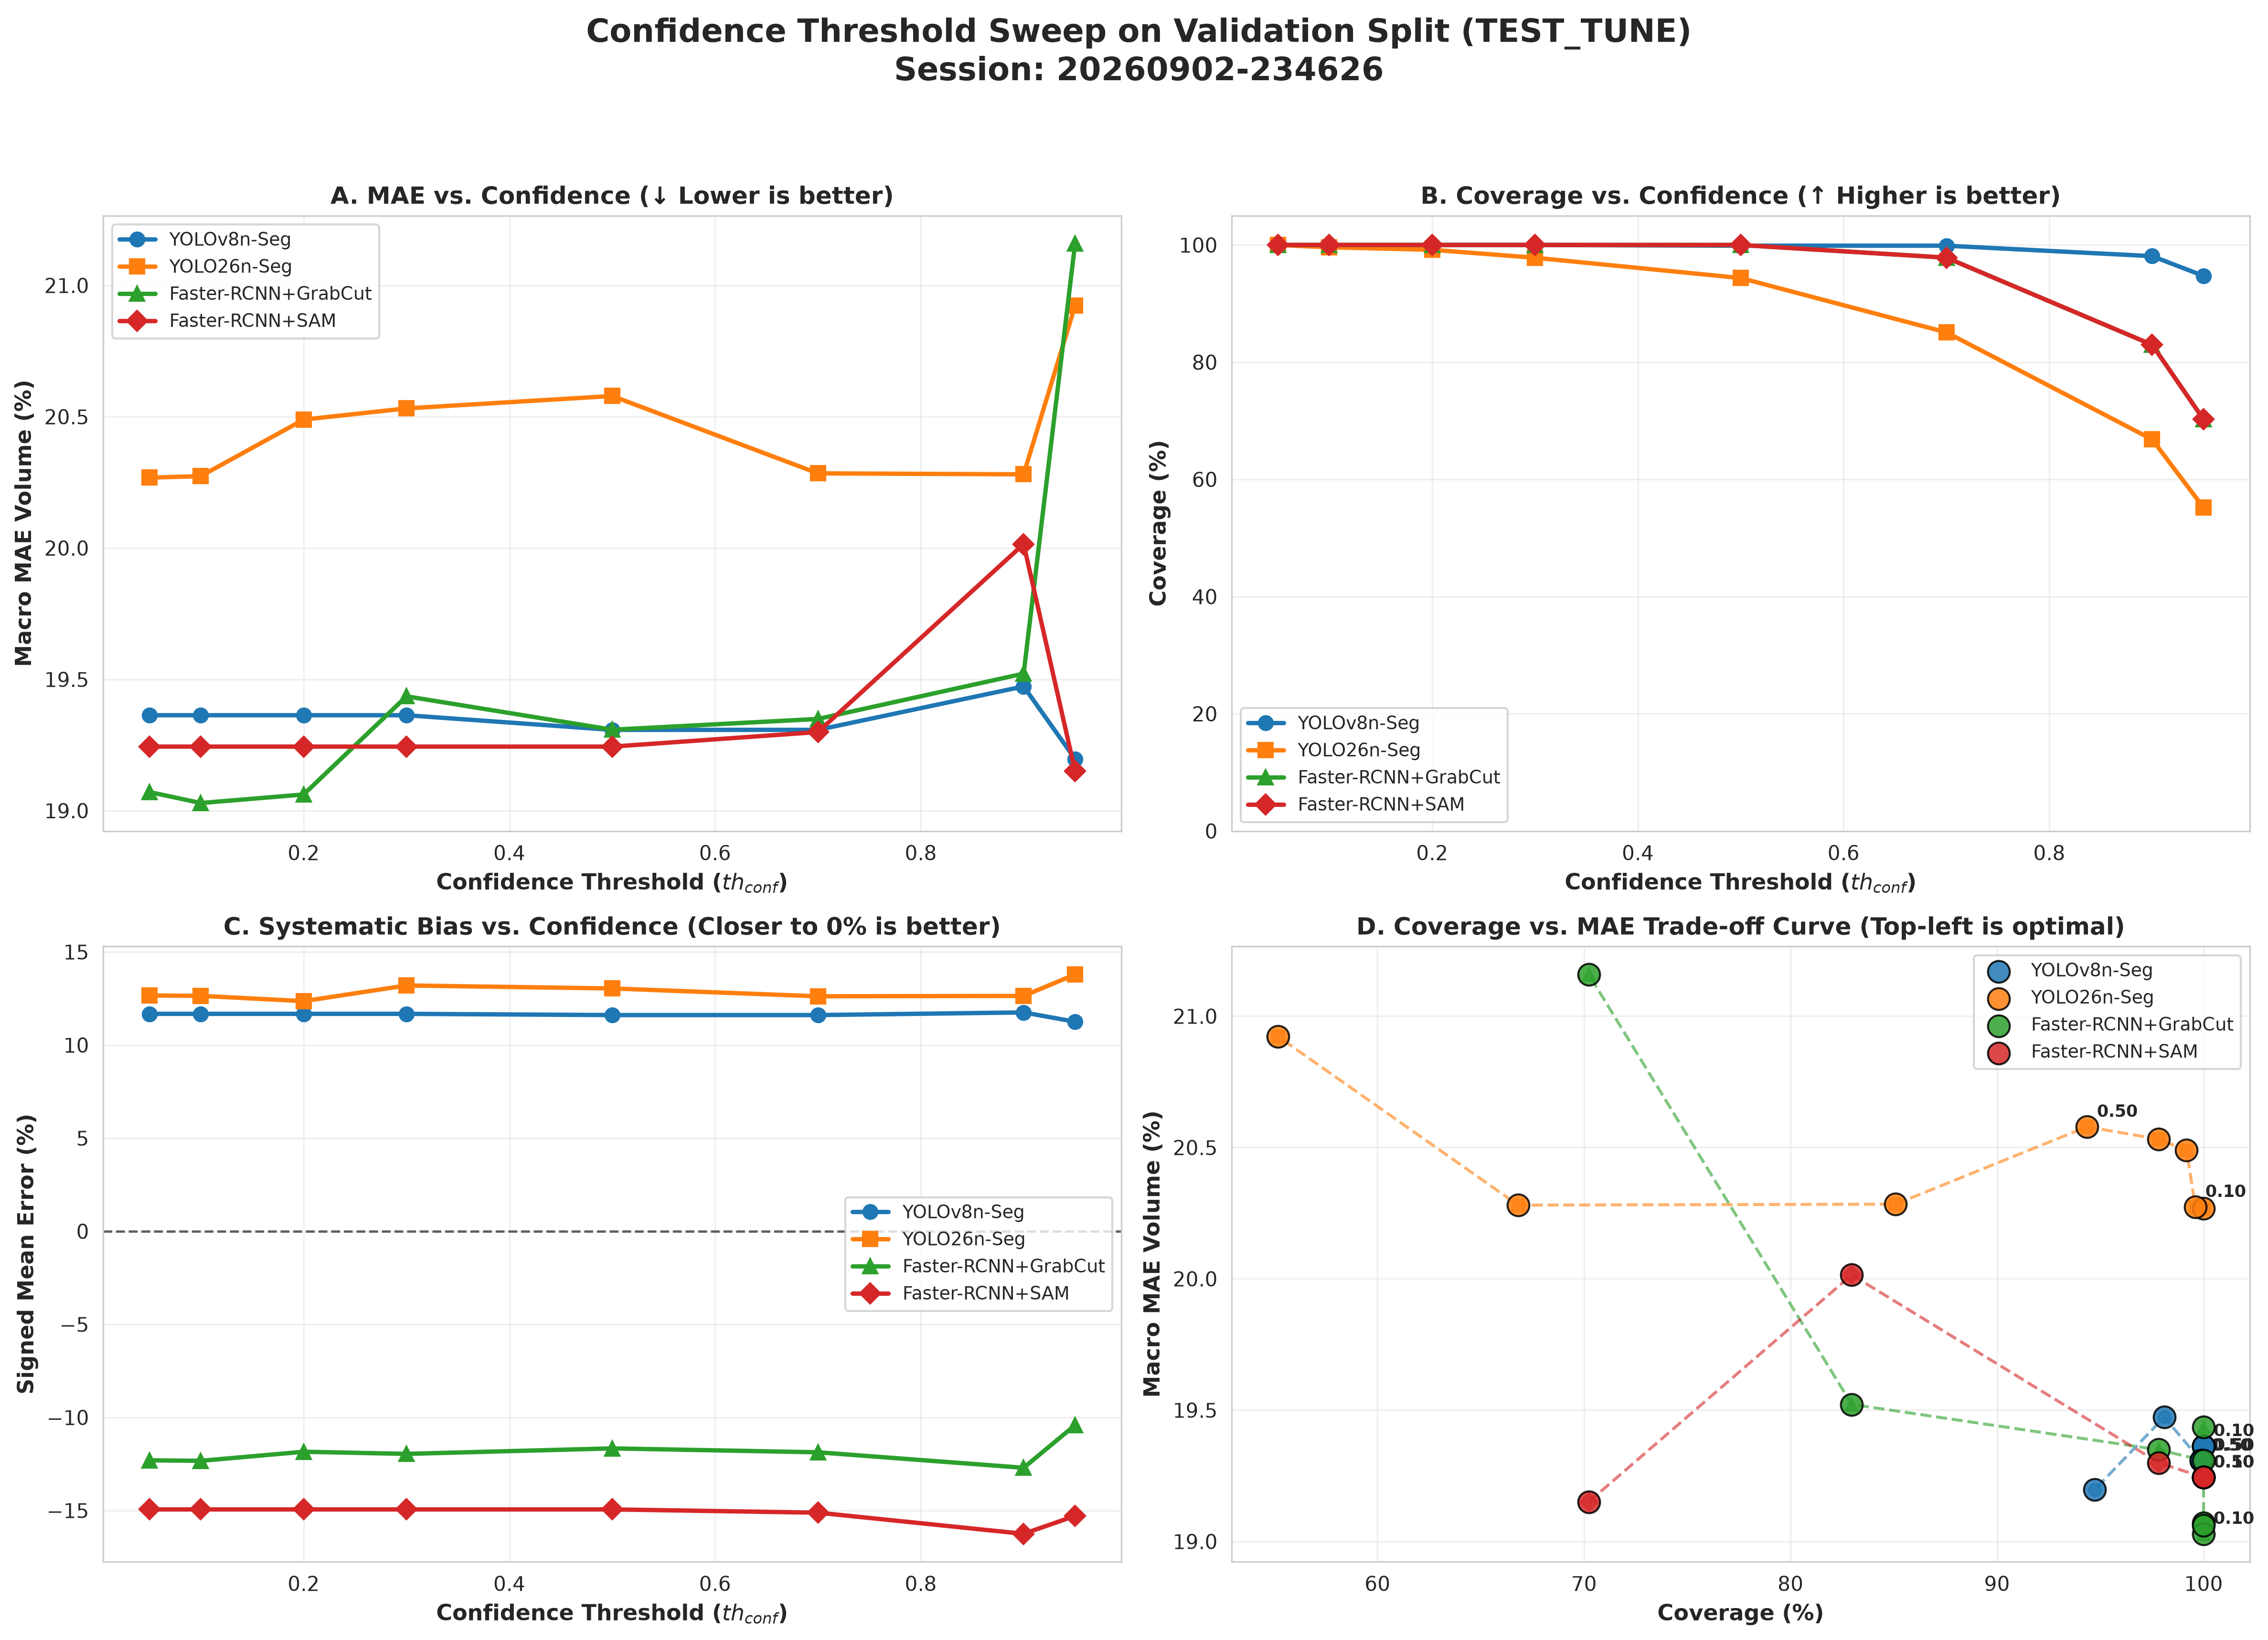

In [6]:
"""Cell 6 -- Visualize threshold sweep results."""

fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=300)
fig.suptitle(f"Confidence Threshold Sweep on Validation Split ({SPLIT.upper()})\nSession: {TIMESTAMP}", 
             fontsize=16, fontweight='bold', y=0.98)

palette = sns.color_palette("tab10", len(results))
model_colors = {name: palette[i] for i, name in enumerate(results.keys())}
markers = {'YOLOv8n-Seg': 'o', 'YOLO26n-Seg': 's', 'Faster-RCNN+GrabCut': '^', 'Faster-RCNN+SAM': 'D'}

for model_name, model_results in results.items():
    df = pd.DataFrame(model_results)
    df = df[~df['mae'].isna()]  # Filter valid runs
    
    if len(df) == 0:
        continue
    
    color = model_colors.get(model_name, 'blue')
    marker = markers.get(model_name, 'o')
    
    # Plot 1: MAE vs Confidence
    axes[0, 0].plot(df['conf'], df['mae'], marker=marker, label=model_name, 
                    linewidth=2.2, markersize=7, color=color)
    
    # Plot 2: Coverage vs Confidence
    axes[0, 1].plot(df['conf'], df['coverage'], marker=marker, label=model_name, 
                    linewidth=2.2, markersize=7, color=color)
    
    # Plot 3: Signed Mean Error (Bias) vs Confidence
    axes[1, 0].plot(df['conf'], df['mean_error'], marker=marker, label=model_name, 
                    linewidth=2.2, markersize=7, color=color)
    
    # Plot 4: Coverage-MAE Trade-off (Top-left is best)
    axes[1, 1].plot(df['coverage'], df['mae'], marker=marker, linewidth=1.5, 
                    linestyle='--', alpha=0.6, color=color)
    axes[1, 1].scatter(df['coverage'], df['mae'], s=120, alpha=0.85, 
                       label=model_name, color=color, edgecolors='black', zorder=5)
    
    # Annotate key thresholds (0.10, 0.25, 0.50, 0.80)
    for _, row in df.iterrows():
        if row['conf'] in [0.10, 0.25, 0.50, 0.80]:
            axes[1, 1].annotate(f"{row['conf']:.2f}", 
                                (row['coverage'], row['mae']),
                                fontsize=8.5, fontweight='semibold',
                                xytext=(5, 5), textcoords='offset points')

# Format Subplot 1
axes[0, 0].set_xlabel("Confidence Threshold ($th_{conf}$)", fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel("Macro MAE Volume (%)", fontsize=11, fontweight='bold')
axes[0, 0].set_title("A. MAE vs. Confidence (↓ Lower is better)", fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=9, loc='best')
axes[0, 0].grid(True, alpha=0.3)

# Format Subplot 2
axes[0, 1].set_xlabel("Confidence Threshold ($th_{conf}$)", fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel("Coverage (%)", fontsize=11, fontweight='bold')
axes[0, 1].set_title("B. Coverage vs. Confidence (↑ Higher is better)", fontsize=12, fontweight='bold')
axes[0, 1].set_ylim(0, 105)
axes[0, 1].legend(fontsize=9, loc='best')
axes[0, 1].grid(True, alpha=0.3)

# Format Subplot 3
axes[1, 0].set_xlabel("Confidence Threshold ($th_{conf}$)", fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel("Signed Mean Error (%)", fontsize=11, fontweight='bold')
axes[1, 0].set_title("C. Systematic Bias vs. Confidence (Closer to 0% is better)", fontsize=12, fontweight='bold')
axes[1, 0].axhline(y=0, color='black', linestyle='--', alpha=0.6, linewidth=1.2)
axes[1, 0].legend(fontsize=9, loc='best')
axes[1, 0].grid(True, alpha=0.3)

# Format Subplot 4
axes[1, 1].set_xlabel("Coverage (%)", fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel("Macro MAE Volume (%)", fontsize=11, fontweight='bold')
axes[1, 1].set_title("D. Coverage vs. MAE Trade-off Curve (Top-left is optimal)", fontsize=12, fontweight='bold')
axes[1, 1].legend(fontsize=9, loc='best')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plot_path = OUTPUT_DIR / "threshold_sweep_visualization.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"\n✓ High-resolution visualization saved: {plot_path}")
plt.show()

In [7]:
"""Cell 7 -- Select best threshold based on Constrained Optimization."""

def select_best_threshold(model_results, min_coverage=85.0, method="constrained"):
    """
    Select best threshold using mathematically sound criteria:
    1. 'constrained': argmin MAE subject to Coverage >= min_coverage (Paper standard).
    2. 'harmonic': Maximize Harmonic Trade-off Score between Coverage and (100 - MAE).
    
    Args:
        model_results (list): List of evaluation result dicts.
        min_coverage (float): Minimum acceptable coverage percentage (e.g. 85.0% or 90.0%).
        method (str): 'constrained' | 'harmonic'
    
    Returns:
        dict: Best threshold record.
    """
    valid_results = [r for r in model_results if not np.isnan(r.get('mae', float('nan')))]
    if not valid_results:
        return None
    
    # Filter by minimum coverage constraint
    constrained_candidates = [r for r in valid_results if r['coverage'] >= min_coverage]
    if not constrained_candidates:
        # Fallback to candidate with maximum coverage if threshold is too strict
        constrained_candidates = sorted(valid_results, key=lambda x: x['coverage'], reverse=True)[:3]
    
    if method == "constrained":
        # Find minimum MAE among valid coverage candidates
        best = min(constrained_candidates, key=lambda x: x['mae'])
        best_record = best.copy()
        best_record['selection_method'] = f"Constrained (min MAE with Coverage >= {min_coverage}%)"
        best_record['score'] = best['coverage'] / (1.0 + best['mae'] / 100.0)
        return best_record
    else:
        # Harmonic score: 2 * Cov * (100 / (100 + MAE)) / (Cov + (100 / (100 + MAE)))
        best = None
        best_score = -float('inf')
        for r in valid_results:
            cov_norm = r['coverage'] / 100.0
            acc_norm = 100.0 / (100.0 + r['mae'])
            h_score = (2.0 * cov_norm * acc_norm) / (cov_norm + acc_norm + 1e-6) * 100.0
            if h_score > best_score:
                best_score = h_score
                best = r.copy()
                best['score'] = h_score
                best['selection_method'] = "Harmonic Trade-off Score"
        return best


# Select optimal thresholds for all evaluated models
best_thresholds = {}

print(f"\n{'='*80}")
print("OPTIMAL THRESHOLD SELECTION (FOR TEST SET FREEZING)")
print("Strategy: Constrained Optimization (argmin MAE s.t. Coverage >= 85.0%)")
print(f"{'='*80}")

for model_name, model_results in results.items():
    best = select_best_threshold(model_results, min_coverage=85.0, method="constrained")
    
    if best:
        best_thresholds[model_name] = best
        print(f"\n{model_name}:")
        print(f"  ✓ Optimal conf (th*) = {best['conf']:.2f}")
        print(f"    Macro MAE Volume   = {best['mae']:.2f}%")
        print(f"    Coverage           = {best['coverage']:.1f}%")
        print(f"    Signed Bias        = {best['mean_error']:.2f}%")
        print(f"    Samples / Pairs    = {best['n_samples']} samples ({best['n_pairs_with_samples']} / {best['total_pairs']} pairs)")
    else:
        print(f"\n{model_name}: ✗ NO VALID THRESHOLD FOUND")

# Save frozen best thresholds to JSON
best_json_path = OUTPUT_DIR / "best_thresholds.json"
with open(best_json_path, "w", encoding="utf-8") as f:
    json.dump(best_thresholds, f, indent=2)

print(f"\n{'='*80}")
print(f"✓ Frozen thresholds successfully exported to: {best_json_path}")
print(f"{'='*80}")


OPTIMAL THRESHOLD SELECTION (FOR TEST SET FREEZING)
Strategy: Constrained Optimization (argmin MAE s.t. Coverage >= 85.0%)

YOLOv8n-Seg:
  ✓ Optimal conf (th*) = 0.95
    Macro MAE Volume   = 19.20%
    Coverage           = 94.7%
    Signed Bias        = 11.25%
    Samples / Pairs    = 6211 samples (6211 / 6557 pairs)

YOLO26n-Seg:
  ✓ Optimal conf (th*) = 0.05
    Macro MAE Volume   = 20.27%
    Coverage           = 100.0%
    Signed Bias        = 12.66%
    Samples / Pairs    = 6557 samples (6557 / 6557 pairs)

Faster-RCNN+GrabCut:
  ✓ Optimal conf (th*) = 0.10
    Macro MAE Volume   = 19.03%
    Coverage           = 100.0%
    Signed Bias        = -12.33%
    Samples / Pairs    = 6557 samples (6557 / 6557 pairs)

Faster-RCNN+SAM:
  ✓ Optimal conf (th*) = 0.05
    Macro MAE Volume   = 19.24%
    Coverage           = 100.0%
    Signed Bias        = -14.94%
    Samples / Pairs    = 6557 samples (6557 / 6557 pairs)

✓ Frozen thresholds successfully exported to: E:\AI_Research\dlt8\outp

In [8]:
"""Cell 8 -- Export benchmark summary table and Markdown report."""

summary_rows = []
for model_name, best in best_thresholds.items():
    summary_rows.append({
        "Model Architecture": model_name,
        "Optimal Conf ($th^*)": f"{best['conf']:.2f}",
        "Macro MAE (%)": f"{best['mae']:.2f}%",
        "Coverage (%)": f"{best['coverage']:.1f}%",
        "Bias (%)": f"{best['mean_error']:.2f}%",
        "Pairs Detected": f"{best['n_pairs_with_samples']}/{best['total_pairs']}",
        "Total Samples": best['n_samples']
    })

summary_df = pd.DataFrame(summary_rows)

print(f"\n{'='*80}")
print("BENCHMARK SUMMARY TABLE (VALIDATION SPLIT -- READY FOR PAPER)")
print(f"{'='*80}")
print(summary_df.to_string(index=False))

# Save CSV table
csv_path = OUTPUT_DIR / "threshold_sweep_summary.csv"
summary_df.to_csv(csv_path, index=False)
print(f"\n✓ Saved summary CSV: {csv_path}")

# Save Comprehensive Markdown Report
md_path = OUTPUT_DIR / "THRESHOLD_SWEEP_REPORT.md"
with open(md_path, "w", encoding="utf-8") as f:
    f.write("# Confidence Threshold Sweep Report\n\n")
    f.write(f"- **Session Timestamp**: `{TIMESTAMP}`\n")
    f.write(f"- **Evaluation Split**: `{SPLIT}`\n")
    f.write("- **Optimization Method**: Constrained Optimization ($\min \text{MAE}$ s.t. $\text{Coverage} \ge 85.0\%$)\n")
    f.write("- **Beta Calibration during Sweep**: `False` (Unbiased baseline sweep)\n\n")
    f.write("## 1. Selected Optimal Thresholds ($th^*$)\n\n")
    f.write(summary_df.to_markdown(index=False))
    f.write("\n\n## 2. Downstream Protocol (STEP 4 & STEP 5)\n\n")
    f.write("1. **Freeze**: Do NOT modify or tune $th^*$ on the Test set.\n")
    f.write("2. **Test Split Evaluation**: Run End-to-End volume and calorie estimation on the **Test Split** (1,733 images) using frozen $th^*$.\n")
    f.write("3. **Beta Calibration ($\beta$)**: Apply 50/50 train-fit $\beta$ scaling in Step 5 to obtain final publication-ready accuracy.\n")
    f.write("4. **Instance Segmentation mAP50**: Compute Mask mAP50 on the Test set.\n")
    f.write("5. **Latency & Throughput (FPS)**: Benchmark End-to-End runtime per image.\n")

print(f"✓ Saved Markdown report: {md_path}")


BENCHMARK SUMMARY TABLE (VALIDATION SPLIT -- READY FOR PAPER)
 Model Architecture Optimal Conf ($th^*) Macro MAE (%) Coverage (%) Bias (%) Pairs Detected  Total Samples
        YOLOv8n-Seg                 0.95        19.20%        94.7%   11.25%      6211/6557           6211
        YOLO26n-Seg                 0.05        20.27%       100.0%   12.66%      6557/6557           6557
Faster-RCNN+GrabCut                 0.10        19.03%       100.0%  -12.33%      6557/6557           6557
    Faster-RCNN+SAM                 0.05        19.24%       100.0%  -14.94%      6557/6557           6557

✓ Saved summary CSV: E:\AI_Research\dlt8\outputs\threshold_sweep\20260902-234626\threshold_sweep_summary.csv
✓ Saved Markdown report: E:\AI_Research\dlt8\outputs\threshold_sweep\20260902-234626\THRESHOLD_SWEEP_REPORT.md


In [9]:
"""Cell 9 -- Final session summary."""

print(f"\n{'='*80}")
print("✓ THRESHOLD SWEEP SESSION COMPLETED SUCCESSFULLY")
print(f"{'='*80}")
print(f"Artifacts directory: {OUTPUT_DIR}\n")
print("Key Artifacts Generated:")
print(f"  1. best_thresholds.json              -> Frozen thresholds for Step 4-5 test evaluation")
print(f"  2. threshold_sweep_summary.csv       -> Summary table in CSV format")
print(f"  3. THRESHOLD_SWEEP_REPORT.md         -> Full Markdown report for research paper")
print(f"  4. threshold_sweep_visualization.png -> Publication-quality 4-panel trade-off figure (300 DPI)")
print(f"  5. [model_name]/sweep_results.json   -> Raw per-threshold metrics per architecture")
print(f"\nNext Step: Proceed with Step 4 (Freeze) & Step 5 (Full Test Set Evaluation).")
print(f"{'='*80}")

if MAX_PAIRS is not None:
    print(f"\n[NOTE] MAX_PAIRS was set to {MAX_PAIRS} (Smoke / Test mode).")
    print("       For final paper publication run, set MAX_PAIRS = None in Cell 2 and re-run.")


✓ THRESHOLD SWEEP SESSION COMPLETED SUCCESSFULLY
Artifacts directory: E:\AI_Research\dlt8\outputs\threshold_sweep\20260902-234626

Key Artifacts Generated:
  1. best_thresholds.json              -> Frozen thresholds for Step 4-5 test evaluation
  2. threshold_sweep_summary.csv       -> Summary table in CSV format
  3. THRESHOLD_SWEEP_REPORT.md         -> Full Markdown report for research paper
  4. threshold_sweep_visualization.png -> Publication-quality 4-panel trade-off figure (300 DPI)
  5. [model_name]/sweep_results.json   -> Raw per-threshold metrics per architecture

Next Step: Proceed with Step 4 (Freeze) & Step 5 (Full Test Set Evaluation).
